# Базовые модели для стекинга: бустинги, беггинг, линейная модель, SVM, KNN

Обучаем семь разнородных базовых ML-моделей на `data/Prepared_data.parquet`
(снапшоты `user_id x cutoff_date`, см. [05_Data-Modeling.ipynb](05_Data-Modeling.ipynb)),
подбираем гиперпараметры на валидации через Optuna, оцениваем на отложенном
cutoff и сохраняем предсказания и сабмиты — это основа для стекинга в
[11_Stacking.ipynb](11_Stacking.ipynb).

## Модели

| Модель | Семейство | Зачем |
|---|---|---|
| CatBoost | бустинг (ordered boosting) | сильная табличная модель, устойчива к переобучению на малом числе cutoff |
| LightGBM | бустинг (leaf-wise) | другой рост деревьев и histogram-биннинг — источник разнообразия для стекинга |
| RandomForest | бэггинг | принципиально другой алгоритм (усреднение независимых деревьев) |
| ElasticNet/Ridge | линейная модель | простая интерпретируемая база, ловит линейный сигнал, которого не видят деревья |
| SGDRegressor | SVM (линейный) | ε-нечувствительный SVM-лосс, но обучается на полном датасете без сабсэмплинга (в отличие от kernel/LinearSVR) |
| Nystroem + Ridge | аппроксимация RBF-ядра | ищет гладкие глобальные нелинейности, недоступные ни линейным моделям, ни деревьям, дёшево по сравнению с kernel SVR |
| FAISS KNN | instance-based | единственная non-parametric модель — прогноз по ближайшим соседям в признаковом пространстве |

Все модели обучаются на `log1p(target_gmv_30d)`/

## Схема валидации

- **Holdout** — последний размеченный cutoff `2026-01-14` целиком исключён из
  подбора гиперпараметров и обучения. Используется только для честной оценки
  качества и как обучающая выборка мета-модели в 11_Stacking.ipynb.
- **CV для Optuna** — оставшиеся 9 cutoff (`2025-04-19` … `2025-12-15`) режутся
  на **3 expanding-window фолда**: train растёт с 6 до 8 cutoff, val — три
  последних cutoff по очереди. Три фолда — баланс между скоростью (3, а не 8,
  обучений на trial) и устойчивостью оценки (каждый фолд валидируется на
  отдельном более позднем cutoff, без утечки будущего).
- **Финальный рефит** — дважды: (1) на 9 non-holdout cutoff → предсказание на
  holdout (оценка качества, error analysis, feature importance); (2) на всех
  10 размеченных cutoff → предсказание на inference cutoff `2026-02-13`
  (реальный сабмит).
- Для CatBoost/LightGBM число деревьев на финальном рефите берётся как среднее
  `best_iteration` по 3 CV-фолдам (с early stopping) — так финальная модель без
  eval_set не переобучается и не видит holdout/inference заранее.

## Импорты, пути, конфигурация скорости

In [1]:
from pathlib import Path
import sys


def _find_project_root():
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path / "data" / "Prepared_data.parquet").exists() and (path / "notebooks").exists():
            return path
    raise FileNotFoundError("Не найден корень проекта с data/Prepared_data.parquet")


sys.path.insert(0, str(_find_project_root() / "src"))


In [ ]:
import os

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")
os.environ.setdefault("VECLIB_MAXIMUM_THREADS", "1")

import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import ElasticNet, Ridge, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import Pipeline

from catboost import CatBoostRegressor
import lightgbm as lgb
import faiss  # pip install faiss-cpu

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import optuna.visualization.matplotlib as ov_mpl

from validation import rmsle
from tabular_data import (
    PROJECT_ROOT,
    SUBMISSIONS_DIR,
    MODELS_DIR,
    OOF_DIR,
    LABELED_CUTOFFS,
    CV_CUTOFFS,
    HOLDOUT_CUTOFF,
    INFERENCE_CUTOFF,
    load_prepared_data,
    get_feature_columns,
    subset_by_cutoffs,
    make_expanding_folds,
    make_xy,
    fit_impute_scale,
    stratified_subsample,
    build_submission_frame,
)

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

MODELS_DIR.mkdir(parents=True, exist_ok=True)
OOF_DIR.mkdir(parents=True, exist_ok=True)

print("project root:", PROJECT_ROOT)


project root: /home/jupyter/project


In [ ]:
USE_GPU = False  # True — ускоряет CatBoost

N_JOBS = 8  # количество ядер CPU

N_TRIALS_CATBOOST = 30
N_TRIALS_LIGHTGBM = 30
N_TRIALS_RF = 15  # + ещё 15 трайлов в отдельной ячейке ниже (итого 30)
N_TRIALS_ELASTICNET = 20
N_TRIALS_SGD = 25  # + ещё 15 трайлов в отдельной ячейке ниже (итого 40)
N_TRIALS_NYSTROEM = 20  # + ещё 15 трайлов в отдельной ячейке ниже (итого 35)
N_TRIALS_KNN = 100

STUDY_TIMEOUT_SECONDS = None  # потолок по времени на study

RF_TRAIN_SUBSAMPLE = 250_000  # размер подвыборки для обучения RandomForest
KNN_TRAIN_SUBSAMPLE = 150_000  # размер подвыборки для обучения KNN
KNN_MAX_NEIGHBORS = 300  # верхняя граница n_neighbors для KNN

EARLY_STOPPING_ROUNDS = 50

faiss.omp_set_num_threads(N_JOBS)


## Загрузка данных

In [4]:
prepared = load_prepared_data()
FEATURE_COLUMNS = get_feature_columns(prepared)

print(f"строк: {len(prepared):,}, признаков: {len(FEATURE_COLUMNS)}")
print(prepared.groupby("cutoff_date").size())

assert len(FEATURE_COLUMNS) == 91
actual_cutoffs = set(pd.DatetimeIndex(prepared["cutoff_date"].unique()))
assert set(LABELED_CUTOFFS) | {INFERENCE_CUTOFF} == actual_cutoffs


строк: 2,597,330, признаков: 91
cutoff_date
2025-04-19    216457
2025-05-19    221154
2025-06-18    225245
2025-07-18    229146
2025-08-17    232977
2025-09-16    236668
2025-10-16    240700
2025-11-15    244983
2025-12-15    250000
2026-01-14    250000
2026-02-13    250000
dtype: int64


## CV-фолды

In [5]:
CV_FOLDS = make_expanding_folds(CV_CUTOFFS, min_train_cutoffs=6)

for fold in CV_FOLDS:
    print(
        f"fold {fold.fold_id}: train={[c.date() for c in fold.train_cutoffs]} "
        f"({len(fold.train_cutoffs)} cutoff) -> val={fold.val_cutoff.date()}"
    )

print("\nholdout cutoff (не участвует в CV):", HOLDOUT_CUTOFF.date())
print("inference cutoff:", INFERENCE_CUTOFF.date())


fold 6: train=[datetime.date(2025, 4, 19), datetime.date(2025, 5, 19), datetime.date(2025, 6, 18), datetime.date(2025, 7, 18), datetime.date(2025, 8, 17), datetime.date(2025, 9, 16)] (6 cutoff) -> val=2025-10-16
fold 7: train=[datetime.date(2025, 4, 19), datetime.date(2025, 5, 19), datetime.date(2025, 6, 18), datetime.date(2025, 7, 18), datetime.date(2025, 8, 17), datetime.date(2025, 9, 16), datetime.date(2025, 10, 16)] (7 cutoff) -> val=2025-11-15
fold 8: train=[datetime.date(2025, 4, 19), datetime.date(2025, 5, 19), datetime.date(2025, 6, 18), datetime.date(2025, 7, 18), datetime.date(2025, 8, 17), datetime.date(2025, 9, 16), datetime.date(2025, 10, 16), datetime.date(2025, 11, 15)] (8 cutoff) -> val=2025-12-15

holdout cutoff (не участвует в CV): 2026-01-14
inference cutoff: 2026-02-13


## Вспомогательные функции

`iterate_folds` строит X/y для каждого CV-фолда один раз за проход (без
повторного чтения parquet — `prepared` уже целиком в памяти).

`fit_final_model` / `predict_gmv` — общий путь для двух финальных рефитов
(на 9 cutoff → holdout, и на 10 cutoff → inference), одинаковый для всех
семи моделей за счёт параметров `preprocessing` (`None` / `"impute"` /
`"scale"`) и `subsample_n`.

In [6]:
def build_fold_data(folds):
    data = []
    for fold in folds:
        X_train, y_train = make_xy(prepared, fold.train_cutoffs, FEATURE_COLUMNS)
        X_val, y_val = make_xy(prepared, [fold.val_cutoff], FEATURE_COLUMNS)
        data.append((fold, X_train, y_train, X_val, y_val))
    return data


# Считаем X/y для всех CV-фолдов один раз — иначе на 100+ optuna trial по 5
# моделям (train до 1.9 млн строк) переизвлечение одних и тех же срезов из
# `prepared` на каждый trial доминировало бы над временем самого обучения.
FOLD_DATA = build_fold_data(CV_FOLDS)


def iterate_folds():
    yield from FOLD_DATA


def rmsle_from_log(y_true_log, preds_raw):
    y_true_raw = np.expm1(np.asarray(y_true_log, dtype="float64"))
    return rmsle(y_true_raw, preds_raw)


def fit_final_model(make_model, preprocessing, subsample_n, train_cutoffs):
    X_train, y_train = make_xy(prepared, train_cutoffs, FEATURE_COLUMNS)
    feature_names = FEATURE_COLUMNS
    if subsample_n is not None:
        X_train, y_train = stratified_subsample(X_train, y_train, y_train > 0, subsample_n, RANDOM_STATE)
    if preprocessing is None:
        transform = lambda X: X
    else:
        transform, feature_names = fit_impute_scale(X_train, scale=(preprocessing == "scale"))
    model = make_model()
    model.fit(transform(X_train), y_train)
    return model, transform, feature_names


def predict_gmv(model, transform, cutoff):
    X, y_log = make_xy(prepared, [cutoff], FEATURE_COLUMNS)
    preds = np.clip(np.expm1(model.predict(transform(X))), 0, None)
    return X.index, preds, y_log


BEST_PARAMS = {}
BEST_N_ESTIMATORS = {}
HOLDOUT_PREDS = {}
FEATURE_IMPORTANCE = {}


## CatBoost

In [ ]:
def catboost_objective(trial):
    params = dict(
        iterations=trial.suggest_int("iterations", 500, 2000, step=100),
        depth=trial.suggest_int("depth", 4, 10),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 15.0, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bylevel=trial.suggest_float("colsample_bylevel", 0.6, 1.0),
        random_strength=trial.suggest_float("random_strength", 0.0, 5.0),
        min_data_in_leaf=trial.suggest_int("min_data_in_leaf", 1, 100, log=True),
    )
    scores, best_iterations = [], []
    for idx, (fold, X_train, y_train, X_val, y_val) in enumerate(iterate_folds()):
        model = CatBoostRegressor(
            **params,
            loss_function="RMSE",
            bootstrap_type="Bernoulli",
            random_seed=RANDOM_STATE,
            task_type="GPU" if USE_GPU else "CPU",
            thread_count=N_JOBS,
            verbose=False,
            allow_writing_files=False,
        )
        model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=EARLY_STOPPING_ROUNDS, use_best_model=True)
        preds = np.clip(np.expm1(model.predict(X_val)), 0, None)
        score = rmsle_from_log(y_val, preds)
        scores.append(score)
        best_iterations.append(model.get_best_iteration() + 1)
        trial.report(score, step=idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
    trial.set_user_attr("best_iterations", best_iterations)
    return float(np.mean(scores))


study_cb = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_warmup_steps=1),
    study_name="catboost",
)
study_cb.optimize(catboost_objective, n_trials=N_TRIALS_CATBOOST, timeout=STUDY_TIMEOUT_SECONDS, show_progress_bar=True)

BEST_PARAMS["catboost"] = study_cb.best_params
BEST_N_ESTIMATORS["catboost"] = int(np.ceil(np.mean(study_cb.best_trial.user_attrs["best_iterations"])))

print("CatBoost CV RMSLE:", study_cb.best_value)
print("best params:", BEST_PARAMS["catboost"])
print("деревьев для финального рефита:", BEST_N_ESTIMATORS["catboost"])


Best trial: 26. Best value: 1.73115: 100%|██████████| 30/30 [6:09:23<00:00, 738.79s/it]   

CatBoost CV RMSLE: 1.7311473353329745
best params: {'iterations': 1900, 'depth': 9, 'learning_rate': 0.03678595817888665, 'l2_leaf_reg': 6.955933897795128, 'subsample': 0.7223797606536271, 'colsample_bylevel': 0.8349077672415648, 'random_strength': 4.2742434496774395, 'min_data_in_leaf': 15}
деревьев для финального рефита: 866


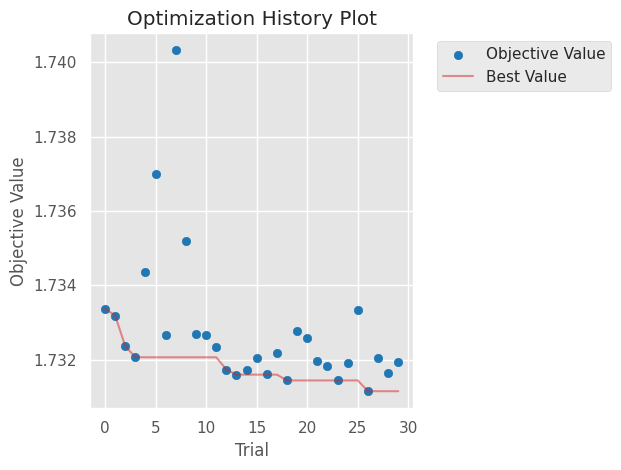

In [ ]:
ov_mpl.plot_optimization_history(study_cb)
plt.tight_layout()
plt.show()


In [7]:
# BEST_PARAMS["catboost"] = {
#     'iterations': 1900, 
#     'depth': 9, 
#     'learning_rate': 0.03678595817888665, 
#     'l2_leaf_reg': 6.955933897795128, 
#     'subsample': 0.7223797606536271, 
#     'colsample_bylevel': 0.8349077672415648, 
#     'random_strength': 4.2742434496774395, 
#     'min_data_in_leaf': 15
# }
# BEST_N_ESTIMATORS["catboost"] = 866

CatBoost holdout RMSLE: 1.68767


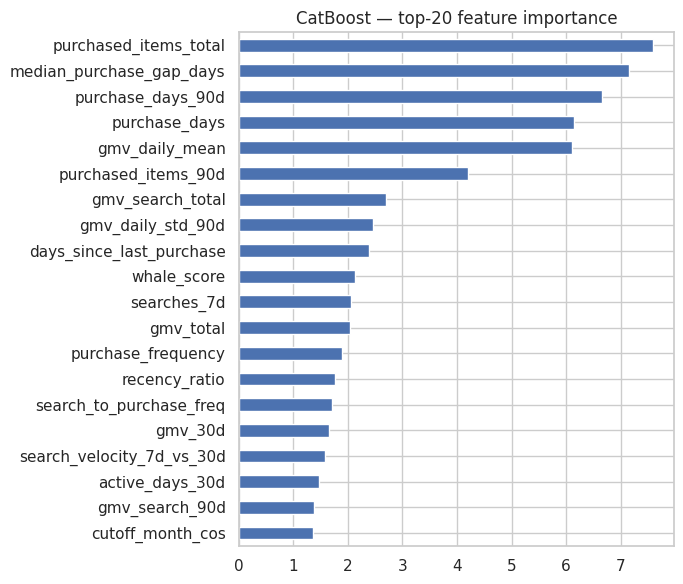

In [8]:
def make_catboost(n_estimators):
    params = dict(BEST_PARAMS["catboost"])
    params["iterations"] = n_estimators
    return CatBoostRegressor(
        **params,
        loss_function="RMSE",
        bootstrap_type="Bernoulli",
        random_seed=RANDOM_STATE,
        task_type="GPU" if USE_GPU else "CPU",
        thread_count=N_JOBS,
        verbose=False,
        allow_writing_files=False,
    )


cb_model, cb_transform, cb_feature_names = fit_final_model(
    make_model=lambda: make_catboost(BEST_N_ESTIMATORS["catboost"]),
    preprocessing=None,
    subsample_n=None,
    train_cutoffs=CV_CUTOFFS,
)

user_ids_hold, preds_hold, y_hold_log = predict_gmv(cb_model, cb_transform, HOLDOUT_CUTOFF)
y_hold_true = np.expm1(y_hold_log.to_numpy())
score_hold = rmsle(y_hold_true, preds_hold)

HOLDOUT_PREDS["catboost"] = pd.Series(preds_hold, index=user_ids_hold, name="catboost")
if "y_true" not in HOLDOUT_PREDS:
    HOLDOUT_PREDS["y_true"] = pd.Series(y_hold_true, index=user_ids_hold, name="y_true")

FEATURE_IMPORTANCE["catboost"] = pd.Series(cb_model.get_feature_importance(), index=cb_feature_names).sort_values(ascending=False)

print(f"CatBoost holdout RMSLE: {score_hold:.5f}")

FEATURE_IMPORTANCE["catboost"].head(20).iloc[::-1].plot.barh(figsize=(7, 6))
plt.title("CatBoost — top-20 feature importance")
plt.tight_layout()
plt.show()


## LightGBM

In [ ]:
def lightgbm_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 500, 2000, step=100),
        num_leaves=trial.suggest_int("num_leaves", 16, 255, log=True),
        max_depth=trial.suggest_int("max_depth", -1, 12),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 100, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    )
    scores, best_iterations = [], []
    for idx, (fold, X_train, y_train, X_val, y_val) in enumerate(iterate_folds()):
        model = lgb.LGBMRegressor(
            **params,
            objective="regression",
            subsample_freq=1,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            verbosity=-1,
        )
        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False), lgb.log_evaluation(0)],
        )
        preds = np.clip(np.expm1(model.predict(X_val)), 0, None)
        score = rmsle_from_log(y_val, preds)
        scores.append(score)
        best_iterations.append(model.best_iteration_)
        trial.report(score, step=idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
    trial.set_user_attr("best_iterations", best_iterations)
    return float(np.mean(scores))


study_lgb = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_warmup_steps=1),
    study_name="lightgbm",
)
study_lgb.optimize(lightgbm_objective, n_trials=N_TRIALS_LIGHTGBM, timeout=STUDY_TIMEOUT_SECONDS, show_progress_bar=True)

BEST_PARAMS["lightgbm"] = study_lgb.best_params
BEST_N_ESTIMATORS["lightgbm"] = int(np.ceil(np.mean(study_lgb.best_trial.user_attrs["best_iterations"])))

print("LightGBM CV RMSLE:", study_lgb.best_value)
print("best params:", BEST_PARAMS["lightgbm"])
print("деревьев для финального рефита:", BEST_N_ESTIMATORS["lightgbm"])


Best trial: 26. Best value: 1.731: 100%|██████████| 30/30 [2:43:45<00:00, 327.52s/it]   

LightGBM CV RMSLE: 1.7309965024069331
best params: {'n_estimators': 1800, 'num_leaves': 187, 'max_depth': 0, 'learning_rate': 0.010193400414754087, 'min_child_samples': 36, 'subsample': 0.8005534398406552, 'colsample_bytree': 0.9477360796635854, 'reg_alpha': 0.001262741288692451, 'reg_lambda': 0.25487277363425137}
деревьев для финального рефита: 1201


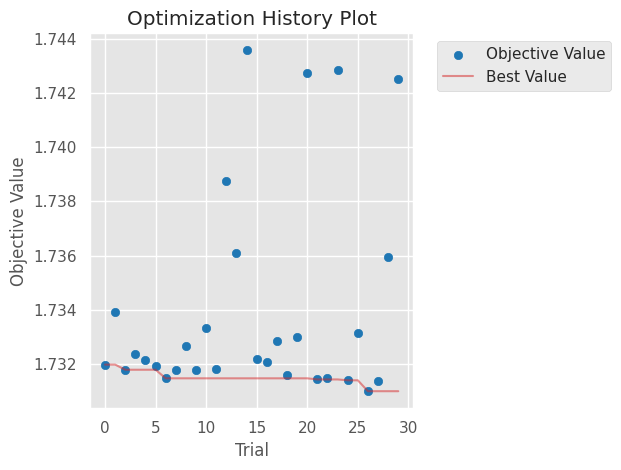

In [ ]:
ov_mpl.plot_optimization_history(study_lgb)
plt.tight_layout()
plt.show()


In [9]:
# BEST_PARAMS["lightgbm"] = {
#     'n_estimators': 1800, 
#     'num_leaves': 187, 
#     'max_depth': 0, 
#     'learning_rate': 0.010193400414754087, 
#     'min_child_samples': 36, 
#     'subsample': 0.8005534398406552, 
#     'colsample_bytree': 0.9477360796635854, 
#     'reg_alpha': 0.001262741288692451, 
#     'reg_lambda': 0.25487277363425137
# }
# BEST_N_ESTIMATORS["lightgbm"] = 1201

LightGBM holdout RMSLE: 1.68542


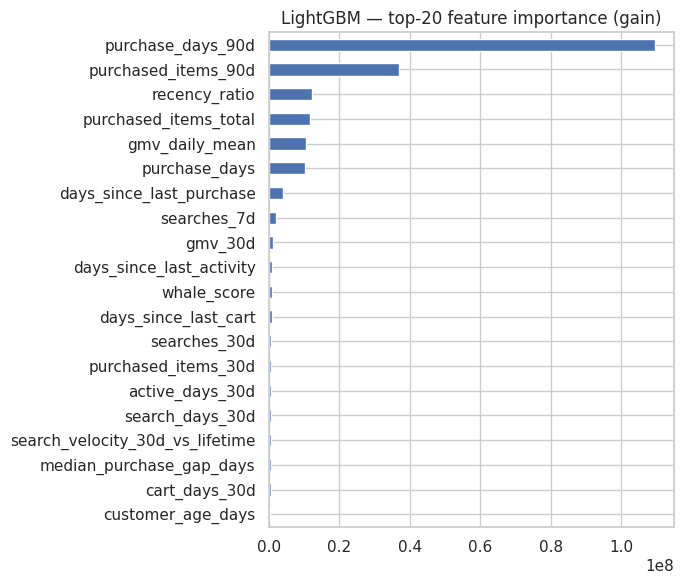

In [10]:
def make_lightgbm(n_estimators):
    params = dict(BEST_PARAMS["lightgbm"])
    params["n_estimators"] = n_estimators
    return lgb.LGBMRegressor(
        **params,
        objective="regression",
        subsample_freq=1,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
        verbosity=-1,
    )


lgb_model, lgb_transform, lgb_feature_names = fit_final_model(
    make_model=lambda: make_lightgbm(BEST_N_ESTIMATORS["lightgbm"]),
    preprocessing=None,
    subsample_n=None,
    train_cutoffs=CV_CUTOFFS,
)

user_ids_hold, preds_hold, y_hold_log = predict_gmv(lgb_model, lgb_transform, HOLDOUT_CUTOFF)
score_hold = rmsle(np.expm1(y_hold_log.to_numpy()), preds_hold)

HOLDOUT_PREDS["lightgbm"] = pd.Series(preds_hold, index=user_ids_hold, name="lightgbm")
FEATURE_IMPORTANCE["lightgbm"] = pd.Series(
    lgb_model.booster_.feature_importance(importance_type="gain"), index=lgb_feature_names
).sort_values(ascending=False)

print(f"LightGBM holdout RMSLE: {score_hold:.5f}")

FEATURE_IMPORTANCE["lightgbm"].head(20).iloc[::-1].plot.barh(figsize=(7, 6))
plt.title("LightGBM — top-20 feature importance (gain)")
plt.tight_layout()
plt.show()


**Наблюдение.** CatBoost и LightGBM независимо сходятся на одних и тех же
топ-признаках — покупательская активность и recency (`purchase_days_90d`,
`purchased_items_90d`, `median_purchase_gap_days`, `gmv_daily_mean`), а не
поисковые или демографические. Две разные модели деревьев видят один и тот же
сигнал.


## RandomForest

`sklearn RandomForestRegressor` не умеет в `NaN`, поэтому используется
`fit_impute_scale(..., scale=False)` — медианная импутация с индикаторами
пропуска, без стандартизации.

Train сэмплируется до `RF_TRAIN_SUBSAMPLE` строк (стратифицированно по
`target > 0`).

In [ ]:
def rf_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 300, step=50),
        max_depth=trial.suggest_int("max_depth", 6, 16),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 100, log=True),
        max_features=trial.suggest_float("max_features", 0.3, 1.0),
        max_samples=trial.suggest_float("max_samples", 0.3, 0.8),
    )
    scores = []
    for idx, (fold, X_train, y_train, X_val, y_val) in enumerate(iterate_folds()):
        X_train_s, y_train_s = stratified_subsample(X_train, y_train, y_train > 0, RF_TRAIN_SUBSAMPLE, RANDOM_STATE)
        transform, _ = fit_impute_scale(X_train_s, scale=False)
        model = RandomForestRegressor(**params, n_jobs=N_JOBS, random_state=RANDOM_STATE)
        model.fit(transform(X_train_s), y_train_s)
        preds = np.clip(np.expm1(model.predict(transform(X_val))), 0, None)
        score = rmsle_from_log(y_val, preds)
        scores.append(score)
        trial.report(score, step=idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(scores))


study_rf = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_warmup_steps=1),
    study_name="random_forest",
)
study_rf.optimize(rf_objective, n_trials=N_TRIALS_RF, timeout=STUDY_TIMEOUT_SECONDS, show_progress_bar=True)

BEST_PARAMS["random_forest"] = study_rf.best_params

print("RandomForest CV RMSLE:", study_rf.best_value)
print("best params:", BEST_PARAMS["random_forest"])


Best trial: 14. Best value: 1.73643: 100%|██████████| 15/15 [1:08:05<00:00, 272.36s/it]

RandomForest CV RMSLE: 1.736426027228082
best params: {'n_estimators': 200, 'max_depth': 13, 'min_samples_leaf': 39, 'max_features': 0.8526339464236253, 'max_samples': 0.4738167152482914}


In [31]:
# Ещё 15 трайлов в тот же самый study
study_rf.optimize(rf_objective, n_trials=15, timeout=STUDY_TIMEOUT_SECONDS, show_progress_bar=True)

BEST_PARAMS["random_forest"] = study_rf.best_params

print("Новый RandomForest CV RMSLE:", study_rf.best_value)
print("Новые best params:", BEST_PARAMS["random_forest"])


Best trial: 28. Best value: 1.73607: 100%|██████████| 15/15 [2:32:39<00:00, 610.66s/it] 

Новый RandomForest CV RMSLE: 1.7360666488348242
Новые best params: {'n_estimators': 300, 'max_depth': 15, 'min_samples_leaf': 26, 'max_features': 0.512937151037094, 'max_samples': 0.7549429820305685}


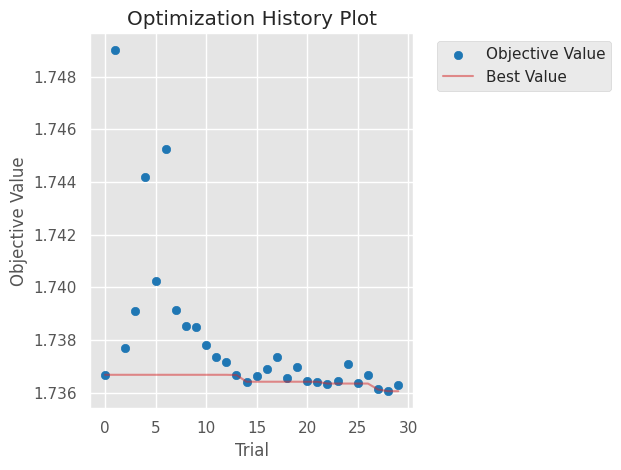

In [32]:
ov_mpl.plot_optimization_history(study_rf)
plt.tight_layout()
plt.show()


In [11]:
# BEST_PARAMS["random_forest"] =  {
#     'n_estimators': 300, 
#     'max_depth': 15, 
#     'min_samples_leaf': 26, 
#     'max_features': 0.512937151037094, 
#     'max_samples': 0.7549429820305685
# }

RandomForest holdout RMSLE: 1.69918


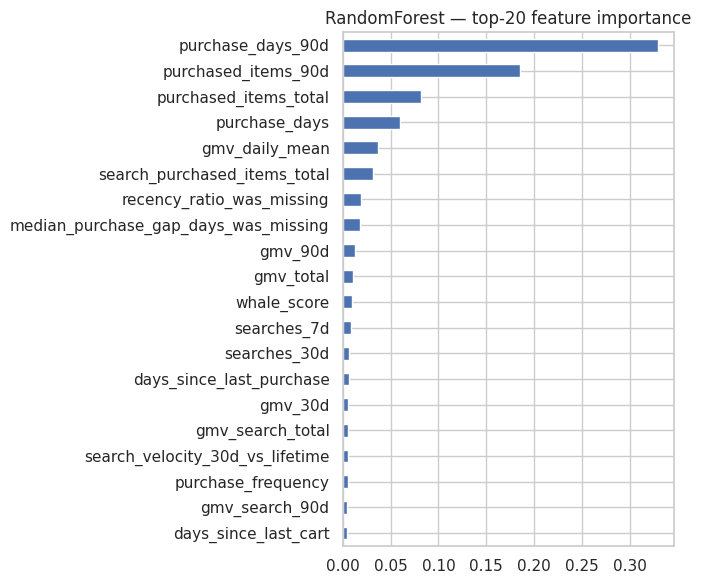

In [12]:
def make_rf():
    return RandomForestRegressor(**BEST_PARAMS["random_forest"], n_jobs=N_JOBS, random_state=RANDOM_STATE)


rf_model, rf_transform, rf_feature_names = fit_final_model(
    make_model=make_rf,
    preprocessing="impute",
    subsample_n=RF_TRAIN_SUBSAMPLE,
    train_cutoffs=CV_CUTOFFS,
)

user_ids_hold, preds_hold, y_hold_log = predict_gmv(rf_model, rf_transform, HOLDOUT_CUTOFF)
score_hold = rmsle(np.expm1(y_hold_log.to_numpy()), preds_hold)

HOLDOUT_PREDS["random_forest"] = pd.Series(preds_hold, index=user_ids_hold, name="random_forest")
FEATURE_IMPORTANCE["random_forest"] = pd.Series(rf_model.feature_importances_, index=rf_feature_names).sort_values(ascending=False)

print(f"RandomForest holdout RMSLE: {score_hold:.5f}")

FEATURE_IMPORTANCE["random_forest"].head(20).iloc[::-1].plot.barh(figsize=(7, 6))
plt.title("RandomForest — top-20 feature importance")
plt.tight_layout()
plt.show()


## ElasticNet / Ridge (линейная модель)

Признаки импутируются медианой (+ индикаторы пропуска) и стандартизируются

In [ ]:
def elasticnet_objective(trial):
    params = dict(
        alpha=trial.suggest_float("alpha", 1e-2, 10.0, log=True),
        l1_ratio=trial.suggest_float("l1_ratio", 0.0, 1.0),
    )
    scores = []
    for idx, (fold, X_train, y_train, X_val, y_val) in enumerate(iterate_folds()):
        transform, _ = fit_impute_scale(X_train, scale=True)
        model = ElasticNet(**params, max_iter=1000, random_state=RANDOM_STATE)
        model.fit(transform(X_train), y_train)
        preds = np.clip(np.expm1(model.predict(transform(X_val))), 0, None)
        score = rmsle_from_log(y_val, preds)
        scores.append(score)
        trial.report(score, step=idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(scores))


study_en = optuna.create_study(
    direction="minimize",
    # Trial идут строго последовательно (n_jobs=1 по умолчанию) — на этом
    # окружении параллельные trial для ElasticNet приводили к зависанию.
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_warmup_steps=1),
    study_name="elasticnet",
)
study_en.optimize(elasticnet_objective, n_trials=N_TRIALS_ELASTICNET, timeout=STUDY_TIMEOUT_SECONDS, show_progress_bar=True)

BEST_PARAMS["elasticnet"] = study_en.best_params

print("ElasticNet CV RMSLE:", study_en.best_value)
print("best params:", BEST_PARAMS["elasticnet"], "(l1_ratio=0 -> Ridge, l1_ratio=1 -> Lasso)")


Best trial: 17. Best value: 1.75985: 100%|██████████| 20/20 [1:05:17<00:00, 195.86s/it]

ElasticNet CV RMSLE: 1.7598482783082623
best params: {'alpha': 0.02072406423173578, 'l1_ratio': 0.08790344580668258} (l1_ratio=0 -> Ridge, l1_ratio=1 -> Lasso)


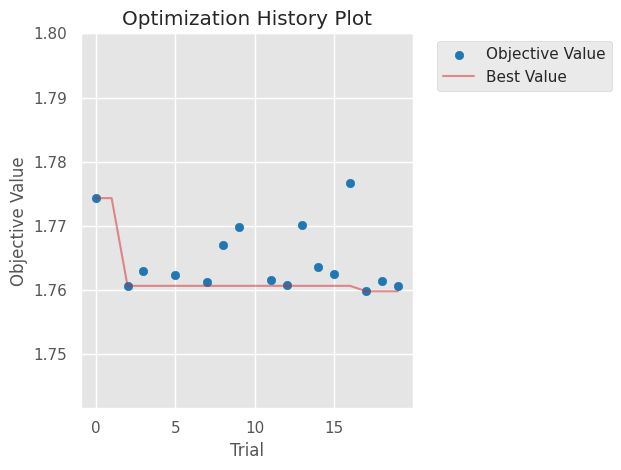

In [18]:
ov_mpl.plot_optimization_history(study_en)
plt.ylim(top=1.8)
plt.tight_layout()
plt.show()


In [13]:
# BEST_PARAMS["elasticnet"] = {
#     'alpha': 0.02072406423173578, 
#     'l1_ratio': 0.08790344580668258
# }

ElasticNet holdout RMSLE: 1.71019


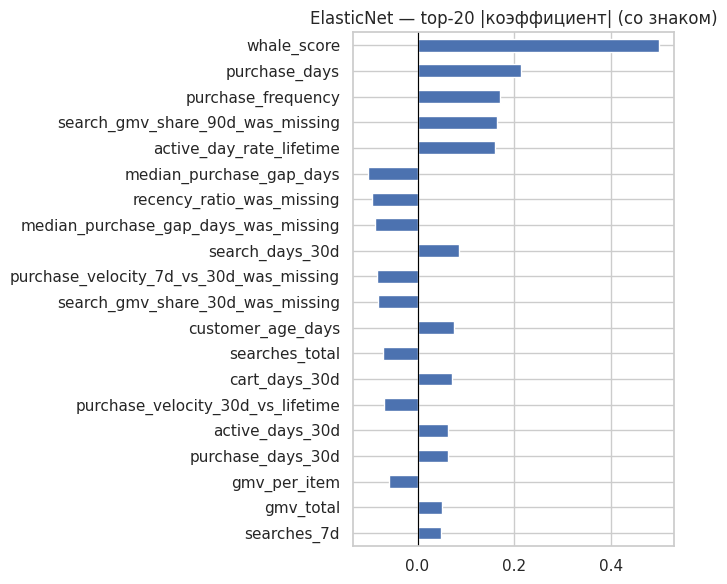

In [14]:
def make_elasticnet():
    return ElasticNet(**BEST_PARAMS["elasticnet"], max_iter=1000, random_state=RANDOM_STATE)


en_model, en_transform, en_feature_names = fit_final_model(
    make_model=make_elasticnet,
    preprocessing="scale",
    subsample_n=None,
    train_cutoffs=CV_CUTOFFS,
)

user_ids_hold, preds_hold, y_hold_log = predict_gmv(en_model, en_transform, HOLDOUT_CUTOFF)
score_hold = rmsle(np.expm1(y_hold_log.to_numpy()), preds_hold)

HOLDOUT_PREDS["elasticnet"] = pd.Series(preds_hold, index=user_ids_hold, name="elasticnet")
# коэффициенты стандартизированных признаков — сопоставимы по модулю между собой
FEATURE_IMPORTANCE["elasticnet"] = pd.Series(en_model.coef_, index=en_feature_names).reindex(
    pd.Series(en_model.coef_, index=en_feature_names).abs().sort_values(ascending=False).index
)

print(f"ElasticNet holdout RMSLE: {score_hold:.5f}")

FEATURE_IMPORTANCE["elasticnet"].head(20).iloc[::-1].plot.barh(figsize=(7, 6))
plt.title("ElasticNet — top-20 |коэффициент| (со знаком)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


## SGDRegressor

`loss="epsilon_insensitive"` — тот же ε-нечувствительный SVM-лосс, что и у
`LinearSVR`, но обучается стохастическим градиентным спуском вместо
liblinear-подобного dual-солвера. Это позволяет учиться на всех ~1.5-1.9 млн
строк train fold без сабсэмплинга (kernel/liblinear-подобные солверы на таком
объёме становятся непозволительно медленными).

In [9]:
def sgd_objective(trial):
    params = dict(
        penalty=trial.suggest_categorical("penalty", ["l2", "l1", "elasticnet"]),
        alpha=trial.suggest_float("alpha", 1e-6, 1e-1, log=True),
        l1_ratio=trial.suggest_float("l1_ratio", 0.0, 1.0),
        epsilon=trial.suggest_float("epsilon", 0.0, 0.5),
        learning_rate=trial.suggest_categorical("learning_rate", ["invscaling", "adaptive", "optimal"]),
        eta0=trial.suggest_float("eta0", 1e-4, 1e-1, log=True),
    )
    scores = []
    for idx, (fold, X_train, y_train, X_val, y_val) in enumerate(iterate_folds()):
        transform, _ = fit_impute_scale(X_train, scale=True)
        model = SGDRegressor(
            **params,
            loss="epsilon_insensitive",
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=5,
            max_iter=1000,
            random_state=RANDOM_STATE,
        )
        model.fit(transform(X_train), y_train)
        preds = np.clip(np.expm1(model.predict(transform(X_val))), 0, None)
        score = rmsle_from_log(y_val, preds)
        scores.append(score)
        trial.report(score, step=idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(scores))


study_sgd = optuna.create_study(
    direction="minimize",
    # trial этой study гоняются параллельно (n_jobs=N_JOBS ниже) — SGDRegressor однопоточный
    sampler=TPESampler(seed=RANDOM_STATE, constant_liar=True),
    pruner=MedianPruner(n_warmup_steps=1),
    study_name="sgd",
)
study_sgd.optimize(sgd_objective, n_trials=N_TRIALS_SGD, timeout=STUDY_TIMEOUT_SECONDS, n_jobs=N_JOBS, show_progress_bar=True)

BEST_PARAMS["sgd"] = study_sgd.best_params

print("SGD CV RMSLE:", study_sgd.best_value)
print("best params:", BEST_PARAMS["sgd"])


Best trial: 22. Best value: 1.80309: 100%|██████████| 25/25 [14:08<00:00, 33.95s/it] 

SGD CV RMSLE: 1.8030882780020983
best params: {'penalty': 'elasticnet', 'alpha': 0.017031089978923362, 'l1_ratio': 0.6625655885234087, 'epsilon': 0.4275368339725552, 'learning_rate': 'optimal', 'eta0': 0.0022590760492685216}


In [11]:
# Ещё 15 трайлов
study_sgd.optimize(sgd_objective, n_trials=15, timeout=STUDY_TIMEOUT_SECONDS, n_jobs=N_JOBS, show_progress_bar=True)

BEST_PARAMS["sgd"] = study_sgd.best_params

print("Новый SGD CV RMSLE:", study_sgd.best_value)
print("Новые best params:", BEST_PARAMS["sgd"])

Best trial: 35. Best value: 1.79827: 100%|██████████| 15/15 [07:00<00:00, 28.01s/it]

Новый SGD CV RMSLE: 1.7982739291167924
Новые best params: {'penalty': 'l2', 'alpha': 0.035345828979368665, 'l1_ratio': 0.8439482104908025, 'epsilon': 0.399039731272916, 'learning_rate': 'optimal', 'eta0': 0.0013144174308478177}


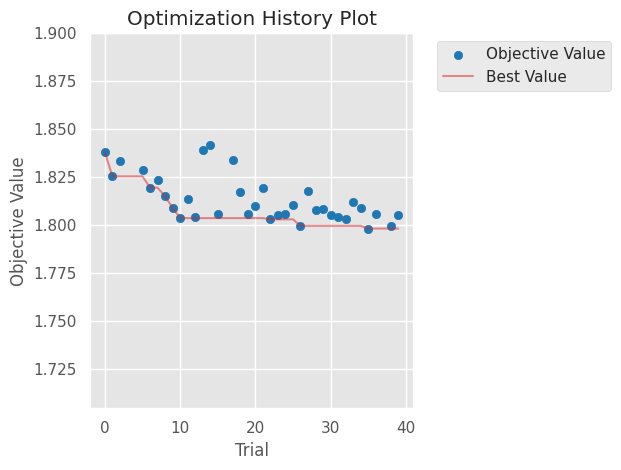

In [14]:
ov_mpl.plot_optimization_history(study_sgd)
plt.ylim(top=1.9)
plt.tight_layout()
plt.show()


In [15]:
# BEST_PARAMS["sgd"] = {
#     'penalty': 'l2', 
#     'alpha': 0.035345828979368665, 
#     'l1_ratio': 0.8439482104908025, 
#     'epsilon': 0.399039731272916, 
#     'learning_rate': 'optimal', 
#     'eta0': 0.0013144174308478177
# }

SGD holdout RMSLE: 1.74624


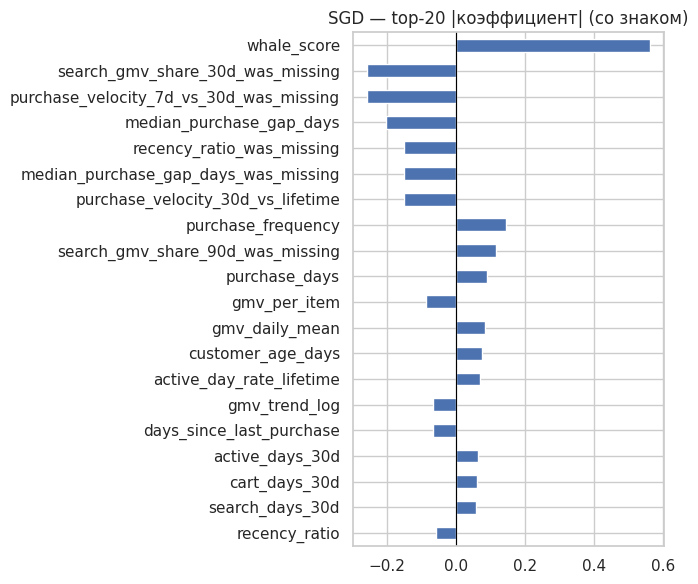

In [16]:
def make_sgd():
    return SGDRegressor(
        **BEST_PARAMS["sgd"],
        loss="epsilon_insensitive",
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=5,
        max_iter=1000,
        random_state=RANDOM_STATE,
    )


sgd_model, sgd_transform, sgd_feature_names = fit_final_model(
    make_model=make_sgd,
    preprocessing="scale",
    subsample_n=None,
    train_cutoffs=CV_CUTOFFS,
)

user_ids_hold, preds_hold, y_hold_log = predict_gmv(sgd_model, sgd_transform, HOLDOUT_CUTOFF)
score_hold = rmsle(np.expm1(y_hold_log.to_numpy()), preds_hold)

HOLDOUT_PREDS["sgd"] = pd.Series(preds_hold, index=user_ids_hold, name="sgd")
FEATURE_IMPORTANCE["sgd"] = pd.Series(sgd_model.coef_, index=sgd_feature_names).reindex(
    pd.Series(sgd_model.coef_, index=sgd_feature_names).abs().sort_values(ascending=False).index
)

print(f"SGD holdout RMSLE: {score_hold:.5f}")

FEATURE_IMPORTANCE["sgd"].head(20).iloc[::-1].plot.barh(figsize=(7, 6))
plt.title("SGD — top-20 |коэффициент| (со знаком)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()


## Nystroem + Ridge (аппроксимация RBF-ядра)

`Nystroem` аппроксимирует RBF-ядро, проецируя объекты на пространство,
построенное по случайной подвыборке `n_components` "опорных" точек, — дальше
поверх этой проекции достаточно обычной линейной `Ridge`-регрессии.

Feature importance для этой модели не считаем: после Nystroem-проекции
коэффициенты Ridge относятся к абстрактному пространству случайных
признаков, а не к исходным 91 колонке — интерпретировать их напрямую
нельзя.

In [16]:
def nystroem_objective(trial):
    n_components = trial.suggest_int("n_components", 50, 400, step=50)
    gamma = trial.suggest_float("gamma", 1e-3, 3.0, log=True)
    alpha = trial.suggest_float("alpha", 1e-3, 100.0, log=True)
    scores = []
    for idx, (fold, X_train, y_train, X_val, y_val) in enumerate(iterate_folds()):
        transform, _ = fit_impute_scale(X_train, scale=True)
        model = Pipeline([
            ("nystroem", Nystroem(kernel="rbf", gamma=gamma, n_components=n_components, random_state=RANDOM_STATE)),
            ("ridge", Ridge(alpha=alpha, random_state=RANDOM_STATE)),
        ])
        model.fit(transform(X_train), y_train)
        preds = np.clip(np.expm1(model.predict(transform(X_val))), 0, None)
        score = rmsle_from_log(y_val, preds)
        scores.append(score)
        trial.report(score, step=idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(scores))


study_nystroem = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_warmup_steps=1),
    study_name="nystroem_ridge",
)
study_nystroem.optimize(nystroem_objective, n_trials=N_TRIALS_NYSTROEM, timeout=STUDY_TIMEOUT_SECONDS, show_progress_bar=True)

BEST_PARAMS["nystroem_ridge"] = study_nystroem.best_params

print("Nystroem+Ridge CV RMSLE:", study_nystroem.best_value)
print("best params:", BEST_PARAMS["nystroem_ridge"])


Best trial: 15. Best value: 1.74039: 100%|██████████| 20/20 [35:56<00:00, 107.81s/it]

Nystroem+Ridge CV RMSLE: 1.7403911503679428
best params: {'n_components': 400, 'gamma': 0.001047391241554554, 'alpha': 22.732883158465693}


In [20]:
# Ещё 15 трайлов
study_nystroem.optimize(nystroem_objective, n_trials=15, timeout=STUDY_TIMEOUT_SECONDS, show_progress_bar=True)

BEST_PARAMS["nystroem_ridge"] = study_nystroem.best_params

print("Новый Nystroem+Ridge CV RMSLE:", study_nystroem.best_value)
print("Новые best params:", BEST_PARAMS["nystroem_ridge"])

Best trial: 15. Best value: 1.74039: 100%|██████████| 15/15 [30:55<00:00, 123.73s/it]

Новый Nystroem+Ridge CV RMSLE: 1.7403911503679428
Новые best params: {'n_components': 400, 'gamma': 0.001047391241554554, 'alpha': 22.732883158465693}


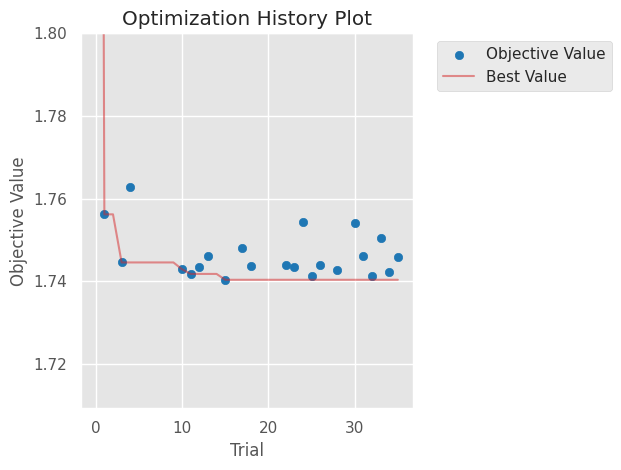

In [26]:
ov_mpl.plot_optimization_history(study_nystroem)
plt.ylim(top=1.8)
plt.tight_layout()
plt.show()


In [17]:
# BEST_PARAMS["nystroem_ridge"] = {
#     'n_components': 400, 
#     'gamma': 0.001047391241554554, 
#     'alpha': 22.732883158465693
# }

In [18]:
def make_nystroem_ridge():
    params = BEST_PARAMS["nystroem_ridge"]
    return Pipeline([
        ("nystroem", Nystroem(kernel="rbf", gamma=params["gamma"], n_components=params["n_components"], random_state=RANDOM_STATE)),
        ("ridge", Ridge(alpha=params["alpha"], random_state=RANDOM_STATE)),
    ])


nystroem_model, nystroem_transform, _ = fit_final_model(
    make_model=make_nystroem_ridge,
    preprocessing="scale",
    subsample_n=None,
    train_cutoffs=CV_CUTOFFS,
)

user_ids_hold, preds_hold, y_hold_log = predict_gmv(nystroem_model, nystroem_transform, HOLDOUT_CUTOFF)
score_hold = rmsle(np.expm1(y_hold_log.to_numpy()), preds_hold)

HOLDOUT_PREDS["nystroem_ridge"] = pd.Series(preds_hold, index=user_ids_hold, name="nystroem_ridge")

print(f"Nystroem+Ridge holdout RMSLE: {score_hold:.5f}")


Nystroem+Ridge holdout RMSLE: 1.69747


## FAISS KNN

Единственная в наборе non-parametric/instance-based модель: прогноз — это
взвешенное по расстоянию среднее `log1p(target)` у `K` ближайших соседей в
импутированном и стандартизированном признаковом пространстве.

Train урезан до `KNN_TRAIN_SUBSAMPLE`.

Feature importance для KNN не считаем.

In [ ]:
class FaissKNNRegressor:
    def __init__(self, n_neighbors=25, weighting="distance"):
        self.n_neighbors = n_neighbors
        self.weighting = weighting

    def fit(self, X, y):
        X = np.ascontiguousarray(X, dtype="float32")
        self.index_ = faiss.IndexFlatL2(X.shape[1])
        self.index_.add(X)
        self.y_train_ = np.asarray(y, dtype="float64")
        return self

    def predict(self, X):
        X = np.ascontiguousarray(X, dtype="float32")
        distances, indices = self.index_.search(X, self.n_neighbors)
        return _aggregate_neighbors(self.y_train_[indices], distances, self.n_neighbors, self.weighting)


def _aggregate_neighbors(neighbor_log, distances, n_neighbors, weighting):
    """Взвешенное усреднение по уже найденным соседям — без единого вызова
    index.search(). neighbor_log/distances могут быть закэшированы на K_max
    neighbors и обрезаны срезом [:, :n_neighbors] для конкретного trial.
    """
    neighbor_log_k = neighbor_log[:, :n_neighbors]
    if weighting == "uniform":
        return neighbor_log_k.mean(axis=1)
    distances_k = distances[:, :n_neighbors]
    weights = 1.0 / np.sqrt(np.maximum(distances_k, 1e-6))
    return (neighbor_log_k * weights).sum(axis=1) / weights.sum(axis=1)


def build_knn_fold_data(fold_data, train_subsample, k_max):
    data = []
    for fold, X_train, y_train, X_val, y_val in fold_data:
        X_train_s, y_train_s = stratified_subsample(X_train, y_train, y_train > 0, train_subsample, RANDOM_STATE)
        transform, _ = fit_impute_scale(X_train_s, scale=True)
        X_train_t = np.ascontiguousarray(transform(X_train_s), dtype="float32")
        X_val_t = np.ascontiguousarray(transform(X_val), dtype="float32")

        index = faiss.IndexFlatL2(X_train_t.shape[1])
        index.add(X_train_t)
        # Единственный дорогой brute-force поиск на весь фолд — сразу на K_max.
        distances, indices = index.search(X_val_t, k_max)
        neighbor_log = y_train_s.to_numpy()[indices]

        data.append((fold, neighbor_log, distances, y_val))
    return data


KNN_FOLD_DATA = build_knn_fold_data(FOLD_DATA, KNN_TRAIN_SUBSAMPLE, KNN_MAX_NEIGHBORS)

In [10]:
def knn_objective(trial):
    n_neighbors = trial.suggest_int("n_neighbors", 5, KNN_MAX_NEIGHBORS, log=True)
    weighting = trial.suggest_categorical("weighting", ["uniform", "distance"])
    scores = []
    for idx, (fold, neighbor_log, distances, y_val) in enumerate(KNN_FOLD_DATA):
        pred_log = _aggregate_neighbors(neighbor_log, distances, n_neighbors, weighting)
        preds = np.clip(np.expm1(pred_log), 0, None)
        score = rmsle_from_log(y_val, preds)
        scores.append(score)
        trial.report(score, step=idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(scores))


study_knn = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_warmup_steps=1),
    study_name="faiss_knn",
)
study_knn.optimize(knn_objective, n_trials=N_TRIALS_KNN, timeout=STUDY_TIMEOUT_SECONDS, show_progress_bar=True)

BEST_PARAMS["faiss_knn"] = study_knn.best_params

print("FAISS KNN CV RMSLE:", study_knn.best_value)
print("best params:", BEST_PARAMS["faiss_knn"])


Best trial: 71. Best value: 1.75917: 100%|██████████| 100/100 [01:54<00:00,  1.14s/it]

FAISS KNN CV RMSLE: 1.7591693919221332
best params: {'n_neighbors': 196, 'weighting': 'distance'}


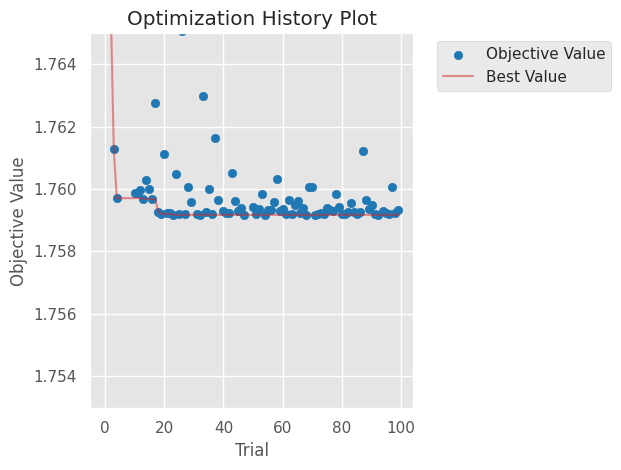

In [14]:
ov_mpl.plot_optimization_history(study_knn)
plt.ylim(top=1.765)
plt.tight_layout()
plt.show()


In [21]:
# BEST_PARAMS["faiss_knn"] = {
#     'n_neighbors': 196, 
#     'weighting': 'distance'
# }

In [22]:
def make_knn():
    return FaissKNNRegressor(**BEST_PARAMS["faiss_knn"])


knn_model, knn_transform, _ = fit_final_model(
    make_model=make_knn,
    preprocessing="scale",
    subsample_n=KNN_TRAIN_SUBSAMPLE,
    train_cutoffs=CV_CUTOFFS,
)

user_ids_hold, preds_hold, y_hold_log = predict_gmv(knn_model, knn_transform, HOLDOUT_CUTOFF)
score_hold = rmsle(np.expm1(y_hold_log.to_numpy()), preds_hold)

HOLDOUT_PREDS["faiss_knn"] = pd.Series(preds_hold, index=user_ids_hold, name="faiss_knn")

print(f"FAISS KNN holdout RMSLE: {score_hold:.5f}")


FAISS KNN holdout RMSLE: 1.72245


## Итоговая таблица holdout / сохранение OOF-предсказаний

Собираем предсказания всех семи моделей на holdout-cutoff в одну широкую
таблицу — она же станет обучающей выборкой мета-модели в 10_Stacking.ipynb.

In [ ]:
MODEL_NAMES = [
    "catboost", "lightgbm", "random_forest", "elasticnet", "sgd", "nystroem_ridge", "faiss_knn",
]

holdout_table = pd.DataFrame({"y_true": HOLDOUT_PREDS["y_true"]})
for name in MODEL_NAMES:
    holdout_table[name] = HOLDOUT_PREDS[name]
holdout_table.index.name = "user_id"

summary = pd.DataFrame({
    "cv_rmsle": {
        "catboost": study_cb.best_value,
        "lightgbm": study_lgb.best_value,
        "random_forest": study_rf.best_value,
        "elasticnet": study_en.best_value,
        "sgd": study_sgd.best_value,
        "nystroem_ridge": study_nystroem.best_value,
        "faiss_knn": study_knn.best_value,
    },
    "holdout_rmsle": {name: rmsle(holdout_table["y_true"], holdout_table[name]) for name in MODEL_NAMES},
}).sort_values("holdout_rmsle")

display(summary)


,cv_rmsle,holdout_rmsle
lightgbm,1.730997,1.685417
catboost,1.731147,1.687667
nystroem_ridge,1.740391,1.697468
random_forest,1.736067,1.699183
elasticnet,1.759848,1.710194
faiss_knn,1.759169,1.722445
sgd,1.798274,1.746244


In [25]:
holdout_table.to_parquet(OOF_DIR / "base_models_holdout.parquet")
print("сохранено:", OOF_DIR / "base_models_holdout.parquet")


сохранено: /home/jupyter/project/data/oof/base_models_holdout.parquet


### Итог по holdout

LightGBM и CatBoost — лучшие (RMSLE ≈ 1.685–1.688), Nystroem+Ridge и
RandomForest близко позади (≈ 1.697–1.699), ElasticNet и FAISS KNN заметно
хуже (≈ 1.71–1.72), SGD — худший результат (≈ 1.746). Ранжирование по CV и по
holdout совпадает — переобучения под CV-фолды не видно.


## Анализ ошибок на holdout

Смотрим не только на средний RMSLE, но и на то, где именно модели ошибаются:
по величине истинного GMV, по пользовательским сегментам, и на конкретных
пользователях с наибольшей ошибкой.

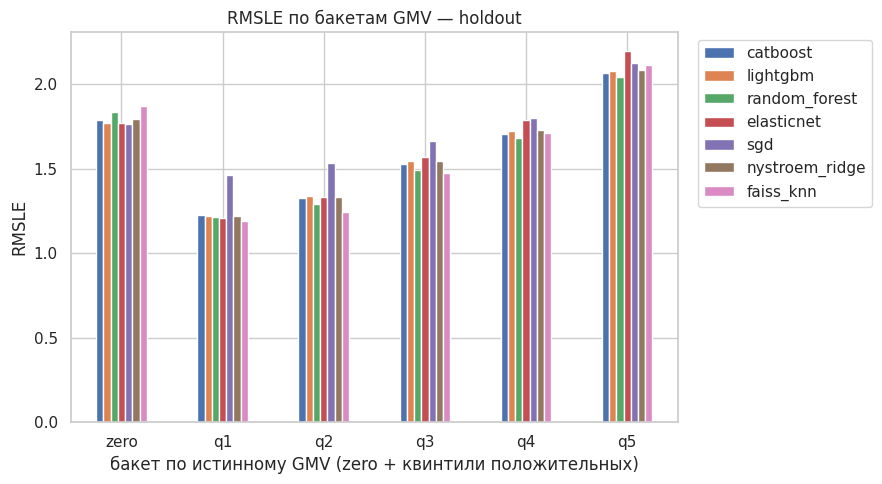

,catboost,lightgbm,random_forest,elasticnet,sgd,nystroem_ridge,faiss_knn
gmv_bucket,,,,,,,
zero,1.787473,1.771596,1.836450,1.771375,1.762243,1.793541,1.872809
q1,1.224211,1.221868,1.214983,1.204928,1.459899,1.218991,1.191472
q2,1.326950,1.339293,1.291715,1.334886,1.532416,1.330265,1.244595
q3,1.528793,1.542975,1.492646,1.566652,1.663665,1.544328,1.475885
q4,1.706712,1.720951,1.679205,1.790212,1.800387,1.730002,1.708614
q5,2.063537,2.075688,2.045004,2.196805,2.125941,2.085394,2.114576


In [28]:
def gmv_bucket(y_true):
    y_true = pd.Series(np.asarray(y_true), index=holdout_table.index)
    bucket = pd.Series("zero", index=y_true.index)
    positive = y_true[y_true > 0]
    if len(positive) > 0:
        bucket.loc[positive.index] = pd.qcut(positive, q=5, labels=[f"q{i + 1}" for i in range(5)], duplicates="drop").astype(str)
    return bucket


holdout_table["gmv_bucket"] = gmv_bucket(holdout_table["y_true"])

bucket_rmsle = pd.DataFrame({
    name: holdout_table.groupby("gmv_bucket").apply(lambda g: rmsle(g["y_true"], g[name]))
    for name in MODEL_NAMES
})
bucket_order = ["zero", "q1", "q2", "q3", "q4", "q5"]
bucket_rmsle = bucket_rmsle.reindex(bucket_order)

ax = bucket_rmsle.plot.bar(figsize=(9, 5)) 
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left') # Выносим легенду за график
plt.ylabel("RMSLE")
plt.xlabel("бакет по истинному GMV (zero + квинтили положительных)")
plt.title("RMSLE по бакетам GMV — holdout")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display(bucket_rmsle)


**Анализ.** Ошибка растёт вместе с бакетом GMV: на `q5` (топ-20% платящих)
RMSLE примерно вдвое выше, чем на `q1`. Бакет `zero` (нулевой GMV) при этом не
даётся моделям проще, чем `q2`–`q3` — любое ненулевое предсказание для такого
пользователя уже создаёт заметную ошибку в log-пространстве. Ранжирование
моделей стабильно внутри каждого бакета: LightGBM/CatBoost впереди, SGD/FAISS
KNN — позади.


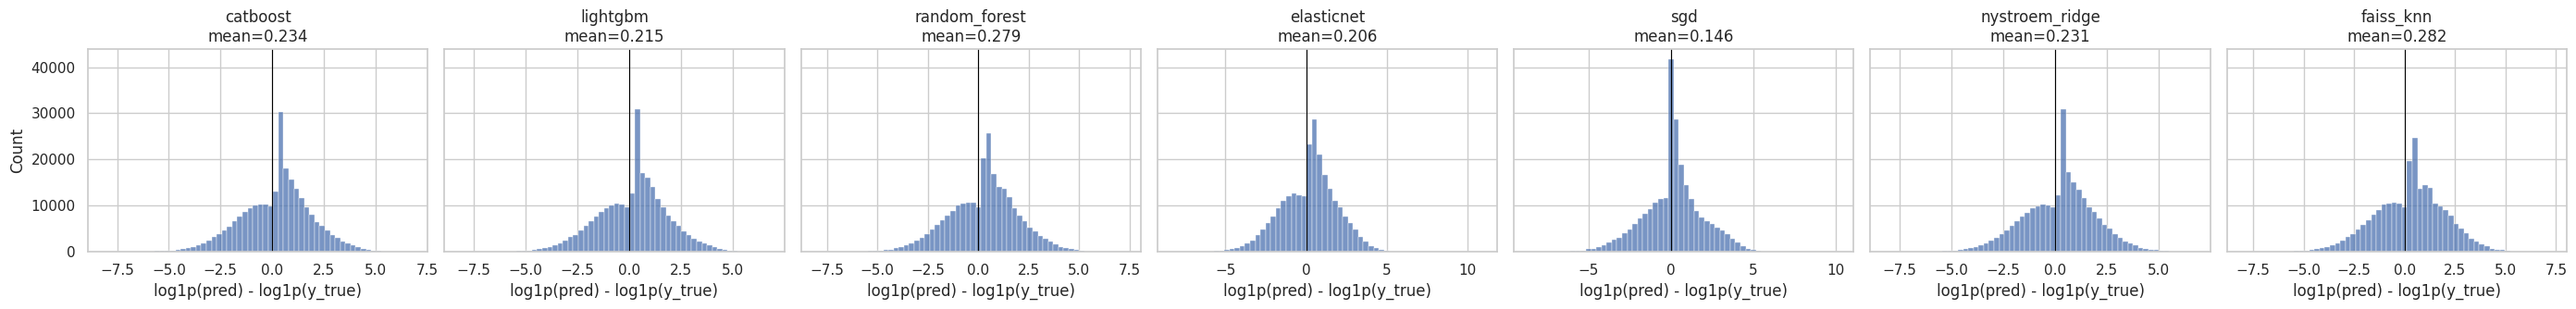

In [29]:
fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(4 * len(MODEL_NAMES), 3.5), sharey=True)
for ax, name in zip(axes, MODEL_NAMES):
    residual = np.log1p(holdout_table[name]) - np.log1p(holdout_table["y_true"])
    sns.histplot(residual, bins=60, ax=ax)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{name}\nmean={residual.mean():.3f}")
    ax.set_xlabel("log1p(pred) - log1p(y_true)")
plt.tight_layout()
plt.show()


**Анализ.** У всех моделей средний остаток положителен (0.15–0.28) —
систематическое завышение, ожидаемое при таргете с большим числом нулей: даже
небольшое положительное предсказание для пользователя с `y_true=0` даёт
положительный вклад в среднее. У SGD смещение минимально (0.146, самые
«осторожные» прогнозы), но именно SGD хуже всех по RMSLE — сглаживание к
среднему снижает смещение ценой более грубых прогнозов на активных
пользователях.


In [30]:
holdout_features = subset_by_cutoffs(prepared, [HOLDOUT_CUTOFF]).set_index("user_id")

whale_p95 = holdout_features["whale_score"].quantile(0.95)
segment = pd.Series("regular", index=holdout_features.index)
segment.loc[holdout_features["never_purchased"] == 1] = "never_purchased"
segment.loc[holdout_features["whale_score"] >= whale_p95] = "whale_top5pct"

holdout_table["segment"] = segment.reindex(holdout_table.index)

segment_rmsle = pd.DataFrame({
    name: holdout_table.groupby("segment").apply(lambda g: rmsle(g["y_true"], g[name]))
    for name in MODEL_NAMES
})
segment_counts = holdout_table["segment"].value_counts()

print(segment_counts)
segment_rmsle


regular            203558
never_purchased     33942
whale_top5pct       12500
Name: segment, dtype: int64


,catboost,lightgbm,random_forest,elasticnet,sgd,nystroem_ridge,faiss_knn
segment,,,,,,,
never_purchased,1.029240,1.027980,1.037397,1.066432,1.054145,1.039242,1.049771
regular,1.782428,1.779918,1.794097,1.795895,1.839739,1.790186,1.818939
whale_top5pct,1.533232,1.533528,1.550951,1.698622,1.688890,1.583308,1.570217


**Анализ.** `never_purchased` — самый простой сегмент (RMSLE ≈ 1.03–1.07):
таргет всегда 0, любая модель предсказывает около нуля. `regular` (203k
пользователей, основная масса) — самый сложный (≈ 1.78–1.84), широкий и не
всегда предсказуемый разброс GMV. `whale_top5pct` (топ-5% по `whale_score`)
при этом ошибается меньше, чем `regular` (≈ 1.53–1.70) — история покупок таких
пользователей стабильнее и сильнее сигнализирует о продолжении высоких трат.
Линейные модели (ElasticNet, SGD) заметно слабее деревьев именно на
whale-сегменте.


In [32]:
best_model_name = summary.index[0]
holdout_table["abs_log_error"] = (np.log1p(holdout_table[best_model_name]) - np.log1p(holdout_table["y_true"])).abs()

worst_users = holdout_table.sort_values("abs_log_error", ascending=False).head(20)
worst_users = worst_users.join(
    holdout_features[["gmv_90d", "whale_score", "days_since_last_purchase", "customer_age_days", "never_purchased"]]
)

print(f"20 худших предсказаний {best_model_name} на holdout по |log1p(pred) - log1p(y_true)|")
display(worst_users[["y_true", best_model_name, "abs_log_error", "gmv_90d", "whale_score", "days_since_last_purchase", "customer_age_days"]])


20 худших предсказаний lightgbm на holdout по |log1p(pred) - log1p(y_true)|


,y_true,lightgbm,abs_log_error,gmv_90d,whale_score,days_since_last_purchase,customer_age_days
user_id,,,,,,,
355760,5408.919974,0.514283,8.181047,0.000000,0.125026,NaN,112
493918,3135.526028,0.495334,7.648522,0.000000,0.125026,NaN,305
529470,2500.391825,0.641852,7.328778,0.000000,0.125026,NaN,321
382829,3390.785730,1.389578,7.257995,21.129637,0.334260,21.0,311
307751,1799.476894,0.391728,7.165261,0.000000,0.125026,NaN,56
669690,1844.452139,0.477599,7.130061,0.000000,0.125026,NaN,379
535525,3265.386585,1.784896,7.067229,47.977207,0.421614,49.0,214
314582,1606.091399,0.494124,6.980641,0.000000,0.125026,NaN,227
246472,3621.746009,2.439815,6.959570,8.496552,0.276576,43.0,368


**Анализ.** Среди худших ошибок LightGBM на holdout — два типа промахов:
* (1) резкая недооценка крупных разовых покупок у пользователей, чья история
активности не давала явного сигнала о всплеске (в т.ч. `days_since_last_purchase
= NaN`, то есть не было покупок в окне признаков); 
* (2) редкие, но заметные
ложные срабатывания — предсказание GMV в сотни пользователям с
фактическим `y_true = 0`, у которых `days_since_last_purchase` равен 0–1
(совсем недавняя активность), притом gmv_90d высокий (много потратили). 

Оба случая — стохастические события, которые сложно
поймать по recency/frequency признакам.


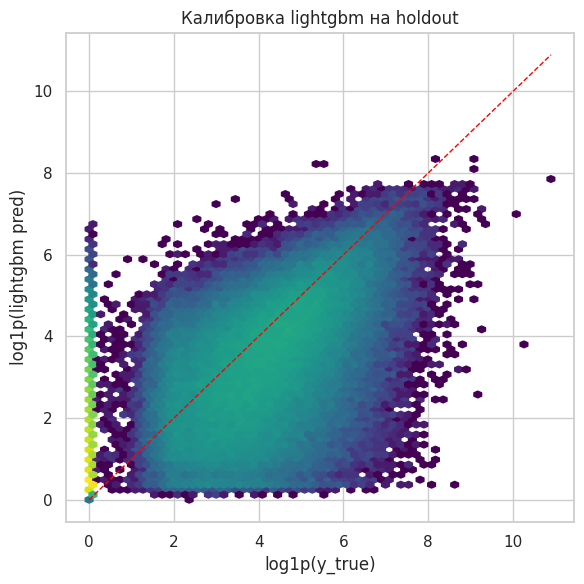

In [33]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.hexbin(
    np.log1p(holdout_table["y_true"]),
    np.log1p(holdout_table[best_model_name]),
    gridsize=60,
    bins="log",
    cmap="viridis",
)
lims = [0, max(np.log1p(holdout_table["y_true"]).max(), np.log1p(holdout_table[best_model_name]).max())]
ax.plot(lims, lims, color="red", linewidth=1, linestyle="--")
ax.set_xlabel("log1p(y_true)")
ax.set_ylabel(f"log1p({best_model_name} pred)")
ax.set_title(f"Калибровка {best_model_name} на holdout")
plt.tight_layout()
plt.show()


**Анализ.** На графике калибровки видно систематическое смещение вниз от
диагонали при больших `log1p(y_true)` — модель тянет прогнозы к среднему и не
достаёт до реальных крупных трат (согласуется с недооценкой whale-сегмента
выше). Вертикальная полоса у `log1p(y_true) = 0` с разбросом предсказаний до
`log1p(pred) ≈ 7` — это и есть ложные срабатывания на пользователях с нулевым
таргетом.


## Сохранение подобранных гиперпараметров

In [34]:
hyperparams_to_save = {
    "catboost": {**BEST_PARAMS["catboost"], "iterations": BEST_N_ESTIMATORS["catboost"]},
    "lightgbm": {**BEST_PARAMS["lightgbm"], "n_estimators": BEST_N_ESTIMATORS["lightgbm"]},
    "random_forest": BEST_PARAMS["random_forest"],
    "elasticnet": BEST_PARAMS["elasticnet"],
    "sgd": BEST_PARAMS["sgd"],
    "nystroem_ridge": BEST_PARAMS["nystroem_ridge"],
    "faiss_knn": BEST_PARAMS["faiss_knn"],
}

with open(MODELS_DIR / "base_hyperparams.json", "w") as f:
    json.dump(hyperparams_to_save, f, indent=2, ensure_ascii=False)

print("сохранено:", MODELS_DIR / "base_hyperparams.json")
hyperparams_to_save


сохранено: /home/jupyter/project/models/base_hyperparams.json


{'catboost': {'iterations': 866,
  'depth': 9,
  'learning_rate': 0.03678595817888665,
  'l2_leaf_reg': 6.955933897795128,
  'subsample': 0.7223797606536271,
  'colsample_bylevel': 0.8349077672415648,
  'random_strength': 4.2742434496774395,
  'min_data_in_leaf': 15},
 'lightgbm': {'n_estimators': 1201,
  'num_leaves': 187,
  'max_depth': 0,
  'learning_rate': 0.010193400414754087,
  'min_child_samples': 36,
  'subsample': 0.8005534398406552,
  'colsample_bytree': 0.9477360796635854,
  'reg_alpha': 0.001262741288692451,
  'reg_lambda': 0.25487277363425137},
 'random_forest': {'n_estimators': 300,
  'max_depth': 15,
  'min_samples_leaf': 26,
  'max_features': 0.512937151037094,
  'max_samples': 0.7549429820305685},
 'elasticnet': {'alpha': 0.02072406423173578, 'l1_ratio': 0.08790344580668258},
 'sgd': {'penalty': 'l2',
  'alpha': 0.035345828979368665,
  'l1_ratio': 0.8439482104908025,
  'epsilon': 0.399039731272916,
  'learning_rate': 'optimal',
  'eta0': 0.0013144174308478177},
 'nystr

## Финальный рефит на всех 10 cutoff + сабмиты

In [35]:
def refit_and_submit(name, make_model, preprocessing, subsample_n, filename):
    model, transform, _ = fit_final_model(make_model, preprocessing, subsample_n, LABELED_CUTOFFS)
    user_ids, preds, _ = predict_gmv(model, transform, INFERENCE_CUTOFF)
    submission = build_submission_frame(user_ids, preds)
    path = SUBMISSIONS_DIR / filename
    submission.to_csv(path, index=False)
    print(f"{name}: сохранено {path} ({len(submission):,} строк)")
    return pd.Series(preds, index=user_ids, name=name)


inference_preds = {}
inference_preds["catboost"] = refit_and_submit(
    "catboost", lambda: make_catboost(BEST_N_ESTIMATORS["catboost"]), None, None, "base_catboost.csv"
)
inference_preds["lightgbm"] = refit_and_submit(
    "lightgbm", lambda: make_lightgbm(BEST_N_ESTIMATORS["lightgbm"]), None, None, "base_lightgbm.csv"
)
inference_preds["random_forest"] = refit_and_submit(
    "random_forest", make_rf, "impute", RF_TRAIN_SUBSAMPLE, "base_random_forest.csv"
)
inference_preds["elasticnet"] = refit_and_submit(
    "elasticnet", make_elasticnet, "scale", None, "base_elasticnet.csv"
)
inference_preds["sgd"] = refit_and_submit(
    "sgd", make_sgd, "scale", None, "base_sgd.csv"
)
inference_preds["nystroem_ridge"] = refit_and_submit(
    "nystroem_ridge", make_nystroem_ridge, "scale", None, "base_nystroem_ridge.csv"
)
inference_preds["faiss_knn"] = refit_and_submit(
    "faiss_knn", make_knn, "scale", KNN_TRAIN_SUBSAMPLE, "base_faiss_knn.csv"
)


catboost: сохранено /home/jupyter/project/submissions/base_catboost.csv (250,000 строк)
lightgbm: сохранено /home/jupyter/project/submissions/base_lightgbm.csv (250,000 строк)
random_forest: сохранено /home/jupyter/project/submissions/base_random_forest.csv (250,000 строк)
elasticnet: сохранено /home/jupyter/project/submissions/base_elasticnet.csv (250,000 строк)
sgd: сохранено /home/jupyter/project/submissions/base_sgd.csv (250,000 строк)
nystroem_ridge: сохранено /home/jupyter/project/submissions/base_nystroem_ridge.csv (250,000 строк)
faiss_knn: сохранено /home/jupyter/project/submissions/base_faiss_knn.csv (250,000 строк)


In [36]:
inference_table = pd.DataFrame(inference_preds)
inference_table.index.name = "user_id"
inference_table.to_parquet(OOF_DIR / "base_models_inference.parquet")

print("сохранено:", OOF_DIR / "base_models_inference.parquet")
inference_table.describe()


сохранено: /home/jupyter/project/data/oof/base_models_inference.parquet


,catboost,lightgbm,random_forest,elasticnet,sgd,nystroem_ridge,faiss_knn
count,250000.000000,250000.000000,250000.000000,2.500000e+05,2.500000e+05,250000.000000,250000.000000
mean,42.998594,41.130400,39.888789,3.096976e+03,1.116276e+04,39.565601,36.816070
std,108.337554,101.658513,105.419834,1.479775e+06,5.499022e+06,87.901917,82.616918
min,0.000000,0.000000,0.094295,0.000000e+00,0.000000e+00,0.000000,0.038511
25%,2.085278,2.053754,1.983909,1.835623e+00,7.287022e-01,1.815950,2.319709
50%,8.852413,8.507148,8.281909,8.233574e+00,8.317651e+00,7.819243,8.955631
75%,37.887144,36.560710,34.588149,3.044595e+01,4.140922e+01,32.980764,32.646077
max,4532.045149,3141.480628,3575.989074,7.398380e+08,2.749472e+09,2332.594482,1723.742992


## Итог и дальнейшие шаги

- Семь базовых моделей обучены, гиперпараметры подобраны Optuna на 3
  expanding-window CV фолдах, качество проверено на holdout-cutoff.
- Лучшие модели по holdout — LightGBM и CatBoost (RMSLE ≈ 1.69); все модели
  систематически недооценивают крупных покупателей (whale) и часть из них
  ошибочно предсказывает заметный GMV пользователям с нулевым фактическим
  таргетом.
- Для каждой модели сохранён отдельный сабмит `submissions/base_*.csv`.
- Гиперпараметры — в `models/base_hyperparams.json`.
- OOF-предсказания на holdout (`data/oof/base_models_holdout.parquet`) и на
  inference cutoff (`data/oof/base_models_inference.parquet`) — входные
  данные для стекинга.
